In [839]:
df = pd.read_csv("bengaluru_house_prices.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [838]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [959]:
df.shape

(10988, 255)

In [841]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [842]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [843]:
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      shape=(2117,), dtype=object)

In [844]:
def sqft_conversion(record):
    try:
        if '-' in record:
            values= record.split('-')
            avg= (float(values[0].strip()) + float(values[1].strip())) / 2
            return avg
        else:
            return float(record)
    except:
        return None
        
df['total_sqft']= df['total_sqft'].apply(sqft_conversion)

In [845]:
df.shape

(13320, 9)

In [846]:
df.dropna(subset= ['total_sqft'], inplace= True)

In [847]:
df.shape

(13274, 9)

In [848]:
df.duplicated().sum()

np.int64(529)

In [849]:
df.drop_duplicates(inplace= True)

In [850]:
df.shape

(12745, 9)

In [851]:
df['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [852]:
df['size']= df['size'].str.split(' ').str[0]

In [853]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200.0,2.0,1.0,51.00


In [854]:
df['size'].isnull().sum()

np.int64(16)

In [855]:
df.dropna(subset= ['size'], inplace= True)

In [856]:
df['size']= df['size'].astype(int)

In [857]:
df.isnull().sum()

area_type          0
availability       0
location           1
size               0
society         5295
total_sqft         0
bath              57
balcony          585
price              0
dtype: int64

In [858]:
df.dropna(subset= ['location'], inplace= True)

In [859]:
df['bath'].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9., nan,  8.,  7., 11., 10., 14.,
       27., 12., 16., 40., 15., 13., 18.])

In [860]:
df.describe()

,size,total_sqft,bath,balcony,price
count,12728.000000,12728.000000,12671.000000,12143.000000,12728.000000
mean,2.816782,1568.765510,2.707127,1.583628,114.228781
std,1.308978,1259.945431,1.355225,0.822034,151.617682
min,1.000000,1.000000,1.000000,0.000000,8.000000
25%,2.000000,1100.000000,2.000000,1.000000,50.000000
50%,3.000000,1280.000000,2.000000,2.000000,73.000000
75%,3.000000,1690.000000,3.000000,2.000000,120.000000
max,43.000000,52272.000000,40.000000,3.000000,3600.000000


In [861]:
df['balcony'].unique()

array([ 1.,  3., nan,  2.,  0.])

In [862]:
df['balcony'].isnull().sum()

np.int64(585)

In [863]:
df['bath'].fillna(value= df['bath'].median(), inplace= True)

C:\Users\Rounak Thorat\AppData\Local\Temp\ipykernel_6352\3369600543.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bath'].fillna(value= df['bath'].median(), inplace= True)


In [864]:
df['bath'].isnull().sum()

np.int64(0)

In [865]:
df['balcony'].fillna(value= df['balcony'].mean(), inplace= True)

C:\Users\Rounak Thorat\AppData\Local\Temp\ipykernel_6352\1805784122.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['balcony'].fillna(value= df['balcony'].mean(), inplace= True)


In [866]:
df['balcony'].isnull().sum()

np.int64(0)

In [867]:
df.isnull().sum()

area_type          0
availability       0
location           0
size               0
society         5295
total_sqft         0
bath               0
balcony            0
price              0
dtype: int64

In [868]:
df.drop(columns= ['society'], inplace= True)

In [869]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [870]:
df.duplicated().sum()

np.int64(39)

In [871]:
df.drop_duplicates(inplace= True)

In [872]:
df.shape

(12689, 8)

In [873]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12689 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12689 non-null  object 
 1   availability  12689 non-null  object 
 2   location      12689 non-null  object 
 3   size          12689 non-null  int64  
 4   total_sqft    12689 non-null  float64
 5   bath          12689 non-null  float64
 6   balcony       12689 non-null  float64
 7   price         12689 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 892.2+ KB


In [874]:
df.head(10)

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2,1056.0,2.0,1.000000,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4,2600.0,5.0,3.000000,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440.0,2.0,3.000000,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,1521.0,3.0,1.000000,95.00
4,Super built-up Area,Ready To Move,Kothanur,2,1200.0,2.0,1.000000,51.00
5,Super built-up Area,Ready To Move,Whitefield,2,1170.0,2.0,1.000000,38.00
6,Super built-up Area,18-May,Old Airport Road,4,2732.0,4.0,1.583628,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,3300.0,4.0,1.583628,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3,1310.0,3.0,1.000000,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6,1020.0,6.0,1.583628,370.00


In [875]:
df['size'].dtype

dtype('int64')

In [876]:
df['size'].head()

0    2
1    4
2    3
3    3
4    2
Name: size, dtype: int64

In [877]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12689 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12689 non-null  object 
 1   availability  12689 non-null  object 
 2   location      12689 non-null  object 
 3   size          12689 non-null  int64  
 4   total_sqft    12689 non-null  float64
 5   bath          12689 non-null  float64
 6   balcony       12689 non-null  float64
 7   price         12689 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 892.2+ KB


In [878]:
df.head(10)

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2,1056.0,2.0,1.000000,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4,2600.0,5.0,3.000000,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3,1440.0,2.0,3.000000,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,1521.0,3.0,1.000000,95.00
4,Super built-up Area,Ready To Move,Kothanur,2,1200.0,2.0,1.000000,51.00
5,Super built-up Area,Ready To Move,Whitefield,2,1170.0,2.0,1.000000,38.00
6,Super built-up Area,18-May,Old Airport Road,4,2732.0,4.0,1.583628,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4,3300.0,4.0,1.583628,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3,1310.0,3.0,1.000000,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6,1020.0,6.0,1.583628,370.00


In [879]:
df['area_type'].value_counts()

area_type
Super built-up  Area    8267
Built-up  Area          2381
Plot  Area              1955
Carpet  Area              86
Name: count, dtype: int64

In [880]:
df['availability'].value_counts()

availability
Ready To Move    10100
18-May             289
18-Dec             282
18-Apr             269
18-Aug             186
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 80, dtype: int64

In [881]:
df['availability']= np.where(df['availability'] == 'Ready To Move', 1, 0)

In [882]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12689 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12689 non-null  object 
 1   availability  12689 non-null  int64  
 2   location      12689 non-null  object 
 3   size          12689 non-null  int64  
 4   total_sqft    12689 non-null  float64
 5   bath          12689 non-null  float64
 6   balcony       12689 non-null  float64
 7   price         12689 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 892.2+ KB


In [883]:
df['location'].value_counts()

location
Whitefield           520
Sarjapur  Road       377
Electronic City      286
Kanakpura Road       240
Thanisandra          228
                    ... 
Vidyapeeta             1
Maruthi Extension      1
Okalipura              1
Old Town               1
Abshot Layout          1
Name: count, Length: 1298, dtype: int64

In [884]:
rare_locations = df['location'].value_counts()[df['location'].value_counts() < 10].index

df['location']= np.where(df['location'].isin(rare_locations), 'other', df['location'])

In [885]:
df['location'].value_counts()

location
other              2773
Whitefield          520
Sarjapur  Road      377
Electronic City     286
Kanakpura Road      240
                   ... 
Naganathapura        10
Kalkere              10
Narayanapura         10
Vasanthapura         10
BEML Layout          10
Name: count, Length: 249, dtype: int64

In [886]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12689 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12689 non-null  object 
 1   availability  12689 non-null  int64  
 2   location      12689 non-null  object 
 3   size          12689 non-null  int64  
 4   total_sqft    12689 non-null  float64
 5   bath          12689 non-null  float64
 6   balcony       12689 non-null  float64
 7   price         12689 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 892.2+ KB


In [887]:
df['bath']= df['bath'].astype('int')
df['balcony']= df['balcony'].astype('int')

In [888]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12689 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12689 non-null  object 
 1   availability  12689 non-null  int64  
 2   location      12689 non-null  object 
 3   size          12689 non-null  int64  
 4   total_sqft    12689 non-null  float64
 5   bath          12689 non-null  int64  
 6   balcony       12689 non-null  int64  
 7   price         12689 non-null  float64
dtypes: float64(2), int64(4), object(2)
memory usage: 892.2+ KB


In [889]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,0,Electronic City Phase II,2,1056.0,2,1,39.07
1,Plot Area,1,Chikka Tirupathi,4,2600.0,5,3,120.00
2,Built-up Area,1,Uttarahalli,3,1440.0,2,3,62.00
3,Super built-up Area,1,Lingadheeranahalli,3,1521.0,3,1,95.00
4,Super built-up Area,1,Kothanur,2,1200.0,2,1,51.00


In [890]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

In [891]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,0,Electronic City Phase II,2,1056.0,2,1,39.07,3699.810606
1,Plot Area,1,Chikka Tirupathi,4,2600.0,5,3,120.00,4615.384615
2,Built-up Area,1,Uttarahalli,3,1440.0,2,3,62.00,4305.555556
3,Super built-up Area,1,Lingadheeranahalli,3,1521.0,3,1,95.00,6245.890861
4,Super built-up Area,1,Kothanur,2,1200.0,2,1,51.00,4250.000000


In [892]:
df['price'] = (df['price'] * 100000)

In [893]:
df.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,0,Electronic City Phase II,2,1056.0,2,1,3907000.0,3699.810606
1,Plot Area,1,Chikka Tirupathi,4,2600.0,5,3,12000000.0,4615.384615
2,Built-up Area,1,Uttarahalli,3,1440.0,2,3,6200000.0,4305.555556
3,Super built-up Area,1,Lingadheeranahalli,3,1521.0,3,1,9500000.0,6245.890861
4,Super built-up Area,1,Kothanur,2,1200.0,2,1,5100000.0,4250.000000


In [894]:
df['price_per_sqft'].describe()

count    1.268900e+04
mean     8.039058e+03
std      1.088525e+05
min      2.678298e+02
25%      4.300000e+03
50%      5.490196e+03
75%      7.407407e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [895]:
df.describe()

,availability,size,total_sqft,bath,balcony,price,price_per_sqft
count,12689.000000,12689.000000,12689.000000,12689.000000,12689.000000,1.268900e+04,1.268900e+04
mean,0.795965,2.818347,1569.800016,2.705729,1.556939,1.143993e+07,8.039058e+03
std,0.403011,1.310433,1261.652791,1.354584,0.812939,1.518104e+07,1.088525e+05
min,0.000000,1.000000,1.000000,1.000000,0.000000,8.000000e+05,2.678298e+02
25%,1.000000,2.000000,1100.000000,2.000000,1.000000,5.000000e+06,4.300000e+03
50%,1.000000,3.000000,1280.000000,2.000000,2.000000,7.300000e+06,5.490196e+03
75%,1.000000,3.000000,1691.000000,3.000000,2.000000,1.210000e+07,7.407407e+03
max,1.000000,43.000000,52272.000000,40.000000,3.000000,3.600000e+08,1.200000e+07


In [896]:
result= []

for i in df['location'].unique():
    location_categories= df[df['location'] == i]
    lower= (location_categories['price_per_sqft'].mean()) - (location_categories['price_per_sqft'].std())
    upper= (location_categories['price_per_sqft'].mean()) + (location_categories['price_per_sqft'].std())
    result.append(location_categories[(location_categories['price_per_sqft'] >= lower) & (location_categories['price_per_sqft'] <= upper)])
    
df= pd.concat(result)

In [897]:
df.shape

(10999, 9)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

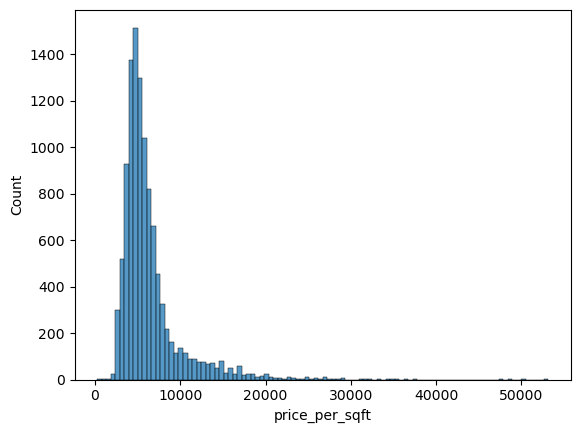

In [898]:
sns.histplot(df['price_per_sqft'], bins= 100)

In [899]:
df['price_per_sqft'].describe()

count    10999.000000
mean      6372.413588
std       3660.658978
min        267.829813
25%       4333.333333
50%       5379.746835
75%       6928.947368
max      53150.000000
Name: price_per_sqft, dtype: float64

In [900]:
top_loc= df.groupby('location')['price_per_sqft'].mean().sort_values(ascending= False).head(10)

In [901]:
top_loc

location
HAL 2nd Stage           24048.279355
Cunningham Road         20335.886586
Sadashiva Nagar         18115.906887
2nd Stage Nagarbhavi    16953.209877
Giri Nagar              15982.897153
Rajaji Nagar            14205.270207
BTM 1st Stage           13792.354181
Benson Town             13525.808027
Mahalakshmi Layout      13243.117318
1st Block Jayanagar     12672.204114
Name: price_per_sqft, dtype: float64

C:\Users\Rounak Thorat\AppData\Local\Temp\ipykernel_6352\3100035216.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_loc.index, x=top_loc.values, palette='Blues_r')


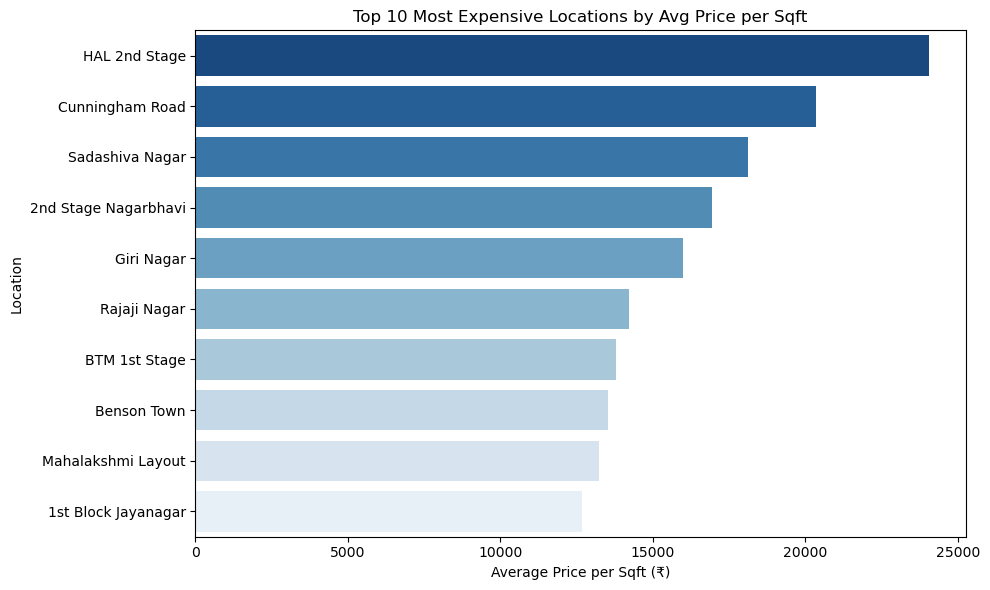

In [902]:
plt.figure(figsize=(10, 6)) # Set size of fig, default size is smaller
sns.barplot(y=top_loc.index, x=top_loc.values, palette='Blues_r')
plt.title('Top 10 Most Expensive Locations by Avg Price per Sqft')
plt.xlabel('Average Price per Sqft (₹)')
plt.ylabel('Location')
plt.tight_layout() # Prevent overlapping
plt.show()

# Always use bar graphs for categorical data & histogram for numerical data.
# Learned about groupby function, it group unique rows and we can perform operations on the group. Its returns a series where index are the groups and values are the output of operations we performed.

HAL 2nd Stage is the most expensive location at ~24,000 rupees per sqft. The top 10 locations are closely priced suggesting Bangalore has a cluster of consistently premium areas rather than one dominant expensive location. This indicates location will be a strong feature in the prediction model

<Axes: xlabel='size', ylabel='price'>

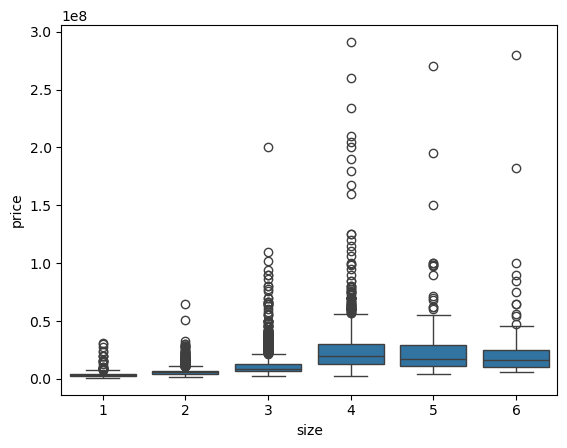

In [903]:
temp= df[df['size'] <= 6]
sns.boxplot(x= temp["size"], y= temp["price"])

Price generally increases with BHK count from 1 to 4 BHK. Beyond 4 BHK the trend becomes inconsistent — likely because 5 and 6 BHK properties are fewer in number making the median less reliable. The relationship is not perfectly linear. High number of outliers across all categories suggests price is influenced by location more than BHK count alone

<Axes: xlabel='bath', ylabel='price'>

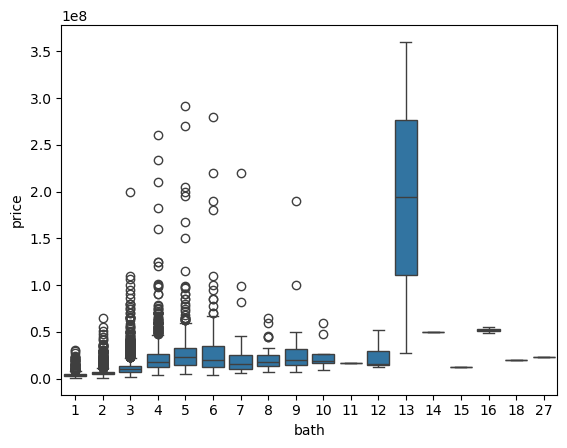

In [904]:
sns.boxplot(x= df["bath"], y= df["price"])

In [905]:
df= df[(df['bath'] <= df['size']+2)]

In [906]:
df.shape

(10988, 9)

<Axes: xlabel='size', ylabel='count'>

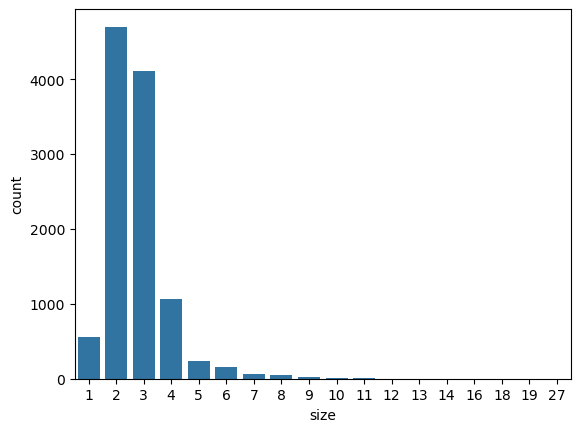

In [907]:
sns.countplot(x=df['size'])

In [908]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10988 entries, 0 to 11869
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       10988 non-null  object 
 1   availability    10988 non-null  int64  
 2   location        10988 non-null  object 
 3   size            10988 non-null  int64  
 4   total_sqft      10988 non-null  float64
 5   bath            10988 non-null  int64  
 6   balcony         10988 non-null  int64  
 7   price           10988 non-null  float64
 8   price_per_sqft  10988 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 858.4+ KB


<Axes: xlabel='area_type', ylabel='price_per_sqft'>

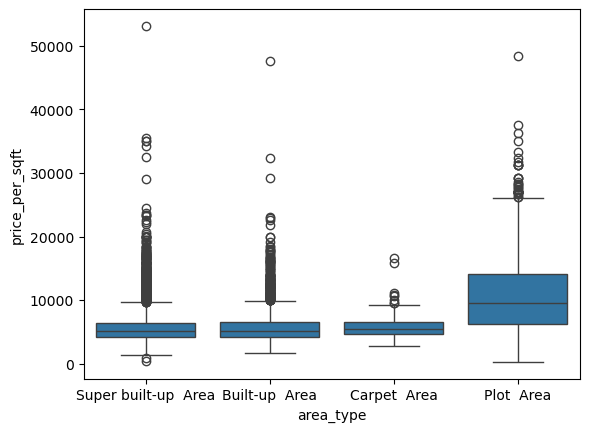

In [909]:
sns.boxplot(x= df["area_type"], y= df["price_per_sqft"])

Plot area being most expensive makes sense — you're buying land itself, not just a flat. Land in Bangalore is scarce and expensive. The box is also very wide meaning plot prices vary a lot depending on location.
Super built-up and Built-up having most outliers — expected because they have the most listings (remember 8267 and 2381 from earlier). More data means more outliers naturally.
Carpet area median similar to super built-up — this is actually interesting. Carpet area is the smallest measurement of a property yet priced similarly per sqft to super built-up. Meaning carpet area properties are genuinely more expensive per usable sqft — which makes real world sense.

<Axes: xlabel='availability', ylabel='price'>

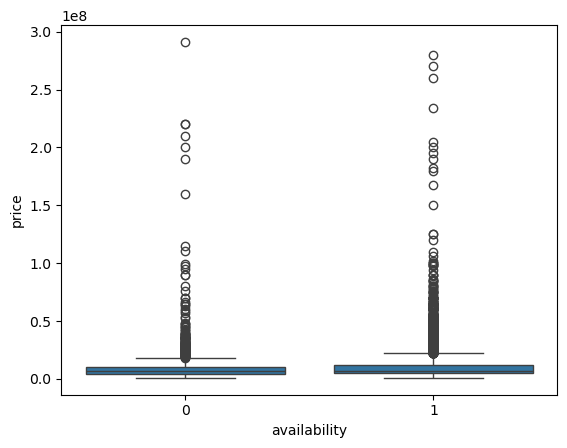

In [910]:
sns.boxplot(x= df["availability"], y= df["price"])

1. Top 10 most expensive locations by average price per sqft
Ans: Bar Plot -> HAL 2nd Stage is the most expensive location at ~24,000 rupees per sqft. The top 10 locations are closely priced with no significant gap between them. This suggests Bangalore has a cluster of consistently premium areas. Location will be a strong predictor in the model.

2. What did you see in the boxplot of BHK vs price
Ans: Box Plot -> Price generally increases with BHK count from 1 to 4 BHK. Beyond 4 BHK the trend becomes inconsistent — likely because 5 and 6 BHK properties are fewer in number making the median less reliable. The relationship is not perfectly linear. High number of outliers across all categories suggests price is influenced by location more than BHK count alone

3. Bathrooms vs price
Ans: Box Plot -> Removed the incorrect bath values the data is somewhat linear But has too many outliers but we can see that it could be related to size more than price So if you combine bath and size we could predict the price more accurately

4. Distribution of BHK count
Ans: Count Plot -> data is baised for 2 and 3 bhk. It will predict these values more accurately that 1, 4, 5 etc

5. Does area type affect price per sqft
Ans: Box Plot -> Plot area being most expensive makes sense — you're buying land itself, not just a flat. Land in Bangalore is scarce and expensive. The box is also very wide meaning plot prices vary a lot depending on location. Super built-up and Built-up having most outliers — expected because they have the most listings (remember 8267 and 2381 from earlier). More data means more outliers naturally. Carpet area median similar to super built-up — this is actually interesting. Carpet area is the smallest measurement of a property yet priced similarly per sqft to super built-up. Meaning carpet area properties are genuinely more expensive per usable sqft — which makes real world sense.

6. Does availability affect price
Ans: Box Plot -> It doesnt and i should remove it.

In [911]:
df.drop(columns= ['availability'], inplace= True)

In [912]:
df.head()

,area_type,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2,1,3907000.0,3699.810606
155,Super built-up Area,Electronic City Phase II,2,1020.0,2,1,3060000.0,3000.000000
292,Super built-up Area,Electronic City Phase II,2,1069.0,2,2,4500000.0,4209.541628
354,Super built-up Area,Electronic City Phase II,1,630.0,1,1,2835000.0,4500.000000
461,Super built-up Area,Electronic City Phase II,3,1220.0,2,1,3523000.0,2887.704918


In [913]:
df.shape

(10988, 8)

In [914]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10988 entries, 0 to 11869
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       10988 non-null  object 
 1   location        10988 non-null  object 
 2   size            10988 non-null  int64  
 3   total_sqft      10988 non-null  float64
 4   bath            10988 non-null  int64  
 5   balcony         10988 non-null  int64  
 6   price           10988 non-null  float64
 7   price_per_sqft  10988 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 772.6+ KB


<Axes: >

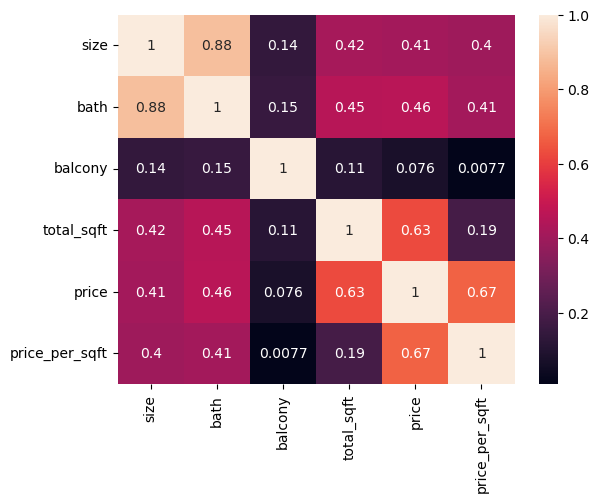

In [915]:
cols = ['size', 'bath', 'balcony', 'total_sqft', 'price', 'price_per_sqft']
sns.heatmap(df[cols].corr(), annot= True)

In [916]:
df= pd.get_dummies(data= df, columns= ['area_type', 'location'], drop_first= True, dtype= int)

In [917]:
df.shape

(10988, 257)

In [918]:
df.head()

,size,total_sqft,bath,balcony,price,price_per_sqft,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Block Jayanagar,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,2,1056.0,2,1,3907000.0,3699.810606,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
155,2,1020.0,2,1,3060000.0,3000.000000,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
292,2,1069.0,2,2,4500000.0,4209.541628,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
354,1,630.0,1,1,2835000.0,4500.000000,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
461,3,1220.0,2,1,3523000.0,2887.704918,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [919]:
df.drop(columns= ['balcony', 'price_per_sqft'], inplace= True)

In [920]:
df.head()

,size,total_sqft,bath,price,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Block Jayanagar,location_1st Block Koramangala,location_1st Phase JP Nagar,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,2,1056.0,2,3907000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
155,2,1020.0,2,3060000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
292,2,1069.0,2,4500000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
354,1,630.0,1,2835000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
461,3,1220.0,2,3523000.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [921]:
from sklearn.model_selection import train_test_split

In [922]:
X = df.drop('price', axis=1)
Y= df['price']

X.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Block Jayanagar,location_1st Block Koramangala,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,2,1056.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
155,2,1020.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
292,2,1069.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
354,1,630.0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
461,3,1220.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [923]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

In [924]:
X_train.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Block Jayanagar,location_1st Block Koramangala,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
4664,2,900.0,2,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2820,3,1300.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10822,4,4303.0,5,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9241,3,1683.0,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4459,3,1868.0,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [925]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, classification_report, confusion_matrix 
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

Models to predict continuous Data 


1. Linear Regression
2. Ridge / Lasso Regression
3. Random Forest Regressor
4. XGBoost Regressor
5. SVR (Support Vector Regressor)
6. KNN Regressor
7. LightGBM
8. CatBoost


Needs scaling:
1. Linear Regression
2. Ridge / Lasso
3. SVR
4. KNN


Doesn't need scaling:
1. Random Forest
2. XGBoost
3. LightGBM
4. CatBoost
5. Decision Tree

In [926]:
scaler= StandardScaler()

X_train_scaled= X_train.copy()
X_test_scaled= X_test.copy()
X_train_scaled[['total_sqft']]= scaler.fit_transform(X_train[['total_sqft']])
X_test_scaled[['total_sqft']]= scaler.transform(X_test[['total_sqft']])

In [927]:
X_train.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Block Jayanagar,location_1st Block Koramangala,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
4664,2,900.0,2,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2820,3,1300.0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10822,4,4303.0,5,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9241,3,1683.0,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4459,3,1868.0,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [928]:
X_train_scaled.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Block Jayanagar,location_1st Block Koramangala,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
4664,2,-0.529441,2,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2820,3,-0.201259,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10822,4,2.262575,5,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9241,3,0.112977,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4459,3,0.264761,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [929]:
X_test.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Block Jayanagar,location_1st Block Koramangala,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
12062,3,1305.0,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7942,4,4000.0,4,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9232,2,1170.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7536,2,1130.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6462,2,965.0,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [930]:
X_test_scaled.head()

,size,total_sqft,bath,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Block Jayanagar,location_1st Block Koramangala,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
12062,3,-0.197156,3,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7942,4,2.013976,4,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9232,2,-0.307918,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7536,2,-0.340736,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6462,2,-0.476112,2,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [931]:
LR_model= LinearRegression()

LR_model.fit(X_train_scaled, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [933]:
LR_pred= LR_model.predict(X_test_scaled)

In [938]:
print("r2:", r2_score(Y_test, LR_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, LR_pred)))
print("MAE:", mean_absolute_error(Y_test, LR_pred))

r2: 0.555768557689378
RMSE: 9733953.000178881
MAE: 3392437.487770232


In [939]:
RR_model= Ridge()

RR_model.fit(X_train_scaled, Y_train)
RR_pred= RR_model.predict(X_test_scaled)

print("r2:", r2_score(Y_test, RR_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, RR_pred)))
print("MAE:", mean_absolute_error(Y_test, RR_pred))

r2: 0.55182753364634
RMSE: 9777035.313137375
MAE: 3396018.0184558495


In [942]:
RF_model= RandomForestRegressor()

In [943]:
RF_model.fit(X_train, Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [944]:
RF_pred= RF_model.predict(X_test)

In [945]:
print("r2:", r2_score(Y_test, RF_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, RF_pred)))
print("MAE:", mean_absolute_error(Y_test, RF_pred))

r2: 0.6615347397870943
RMSE: 8496531.02656268
MAE: 2945357.439317873


In [946]:
XGB_model= XGBRegressor()

In [947]:
XGB_model.fit(X_train, Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [949]:
XGB_pred= XGB_model.predict(X_test)

In [950]:
print("r2:", r2_score(Y_test, XGB_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, XGB_pred)))
print("MAE:", mean_absolute_error(Y_test, XGB_pred))

r2: 0.6516828213688055
RMSE: 8619300.950857261
MAE: 2932950.2242663787


In [951]:
LGBM_model= LGBMRegressor()

LGBM_model.fit(X_train, Y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 8790, number of used features: 102
[LightGBM] [Info] Start training from score 10537450.284414


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [952]:
LGBM_pred= LGBM_model.predict(X_test)

In [953]:
print("r2:", r2_score(Y_test, LGBM_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, LGBM_pred)))
print("MAE:", mean_absolute_error(Y_test, LGBM_pred))

r2: 0.681376684930052
RMSE: 8243722.682171176
MAE: 3073695.2082099803


In [954]:
params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 70]
}

rs = RandomizedSearchCV(
    estimator=LGBMRegressor(),
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42
)

rs.fit(X_train, Y_train)
print(rs.best_params_)
print(rs.best_score_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000199 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 439
[LightGBM] [Info] Number of data points in the train set: 7032, number of used features: 81
[LightGBM] [Info] Start training from score 10553321.459044
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

In [956]:
LGBM_model_tunned= LGBMRegressor(num_leaves=70, n_estimators=200, max_depth=7, learning_rate=0.1)

LGBM_model_tunned.fit(X_train, Y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 8790, number of used features: 102
[LightGBM] [Info] Start training from score 10537450.284414
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,boosting_type,'gbdt'
,num_leaves,70
,max_depth,7
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [957]:
LGBM_pred_tunned= LGBM_model_tunned.predict(X_test)

In [958]:
print("r2:", r2_score(Y_test, LGBM_pred_tunned))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, LGBM_pred_tunned)))
print("MAE:", mean_absolute_error(Y_test, LGBM_pred_tunned))

r2: 0.6991157259676828
RMSE: 8010955.929924056
MAE: 3059911.3932789345


In [960]:
Y_train.describe()

count    8.790000e+03
mean     1.053745e+07
std      1.302719e+07
min      8.000000e+05
25%      5.000000e+06
50%      7.000000e+06
75%      1.100000e+07
max      2.912000e+08
Name: price, dtype: float64

In [961]:
X_train.shape

(8790, 254)

In [964]:
X_train.isnull().sum().sum()

np.int64(0)